**Real Estate Price Prediction**

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.shape # To display the number of rows and columns in the dataset

(13320, 9)

In [3]:
df.info() #To display the summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
df.head() # To display the first five rows of the dataset

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.describe() # To display the statistics of the dataset

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [6]:
df.isnull().sum() # To display the number of missing values in each column

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

**Data Cleaning and Preprocessing**

In [7]:
# Handling Missing Values: (location)
df['location'] = df['location'].fillna('Unknown')
df['location'] = df['location'].str.strip()

In [8]:
#size
df['size'] = df['size'].fillna(df['size'].mode()[0])

In [9]:
# society
df['society'] = df['society'].fillna('Unknown')
df['society'] = df['society'].str.strip()

# bath
df['bath'] = df['bath'].fillna(df['bath'].median())

# balcony
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [10]:
df.info() # Checking the dataset to ensure missing values are not present


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13320 non-null  object 
 4   society       13320 non-null  object 
 5   total_sqft    13320 non-null  object 
 6   bath          13320 non-null  float64
 7   balcony       13320 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [11]:
df.describe()

,bath,balcony,price
count,13320.000000,13320.000000,13320.000000
mean,2.688814,1.603378,112.565627
std,1.338754,0.803067,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [12]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,Unknown,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,Unknown,1200,2.0,1.0,51.00


In [13]:
# Extract only number from total_sqft
df['total_sqft'] = df['total_sqft'].str.extract(r'(\d+\.?\d*)').astype(float)

In [14]:
df['price'] = df['price'].astype(float)

df['total_sqft'] = df['total_sqft'].astype(float)

In [15]:
# Removing Outliers using Percentile
lower_sqft = df['total_sqft'].quantile(0.01)
upper_sqft = df['total_sqft'].quantile(0.99)
df = df[(df['total_sqft'] >= lower_sqft) & (df['total_sqft'] <= upper_sqft)]

In [16]:
lower_price = df['price'].quantile(0.01)
upper_price = df['price'].quantile(0.99)
df = df[(df['price'] >= lower_price) & (df['price'] <= upper_price)]

**Exploratory Data Analysis**

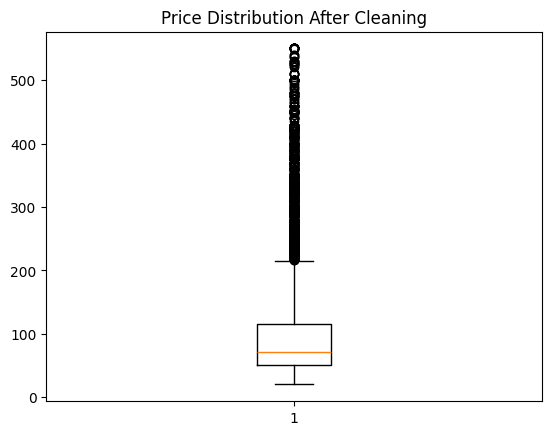

In [17]:
# Visualisation of Price and Total_sqft after cleaning
plt.boxplot(df['price'])
plt.title("Price Distribution After Cleaning")
plt.show()

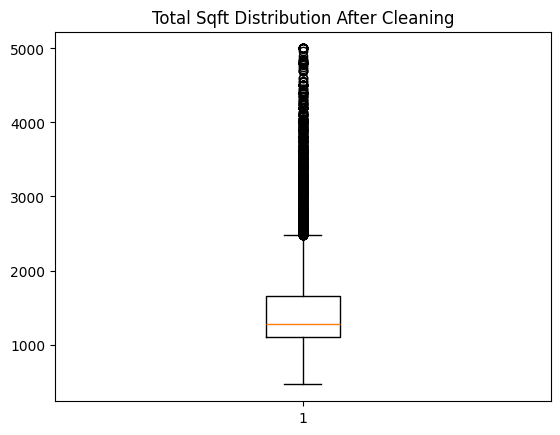

In [18]:
plt.boxplot(df['total_sqft'])
plt.title("Total Sqft Distribution After Cleaning")
plt.show()


In [19]:
# Saving the dataset
df.to_csv('Bengaluru_data.csv', index=False)

In [20]:
# Extract bhk from size column

df['bhk'] = df['size'].str.extract(r'(\d+)')
 # extract numbers
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce') # convert to numeric
df['bhk'] = df['bhk'].fillna(df['bhk'].mode()[0]).astype(int)

In [21]:
# Reduce location complexity
location_stats = df['location'].value_counts()
rare_locations = location_stats[location_stats <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [ ]:
# Feature: price per sqft
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
 # Remove extreme price_per_sqft outliers
lower_pps = df['price_per_sqft'].quantile(0.01)
upper_pps = df['price_per_sqft'].quantile(0.99)

df = df[(df['price_per_sqft'] >= lower_pps) & (df['price_per_sqft'] <= upper_pps)]

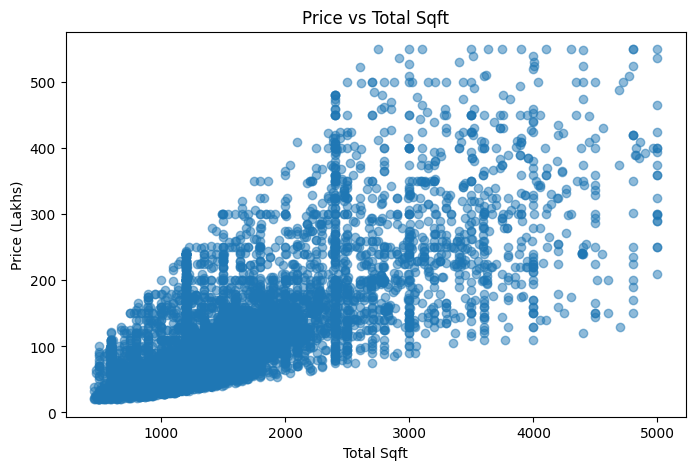

In [23]:
# One-Hot Encoding for categorical variables
df_final = pd.get_dummies(df, columns=['location', 'area_type'], drop_first=True)

# EDAPlots
plt.figure(figsize=(8,5))
plt.scatter(df['total_sqft'], df['price'], alpha=0.5)
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.title('Price vs Total Sqft')
plt.show()


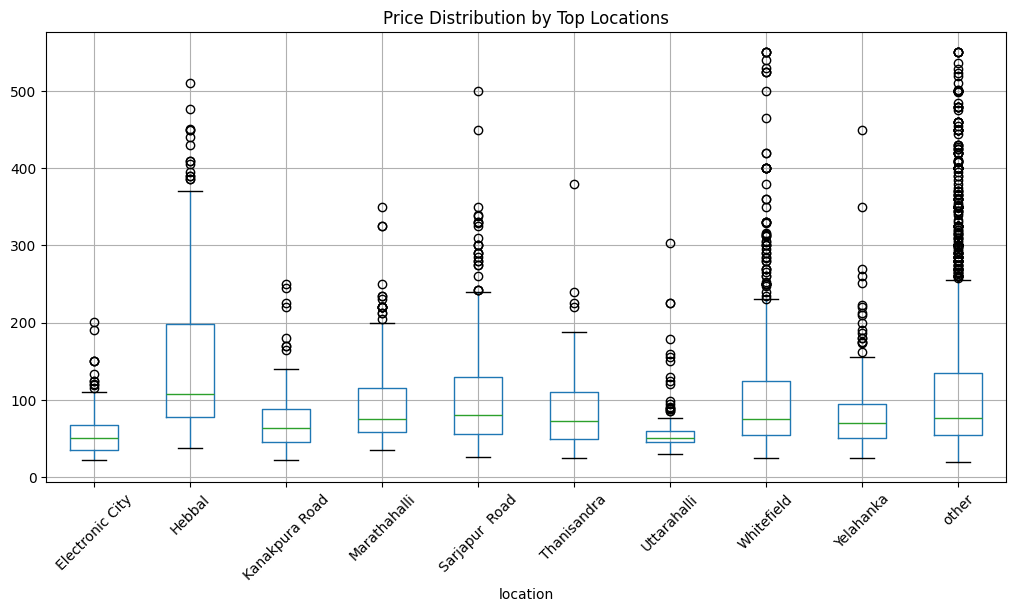

In [24]:
top_locations = df['location'].value_counts().head(10).index
df[df['location'].isin(top_locations)].boxplot(column='price', by='location', figsize=(12,6))
plt.xticks(rotation=45)
plt.title('Price Distribution by Top Locations')
plt.suptitle('')
plt.show()

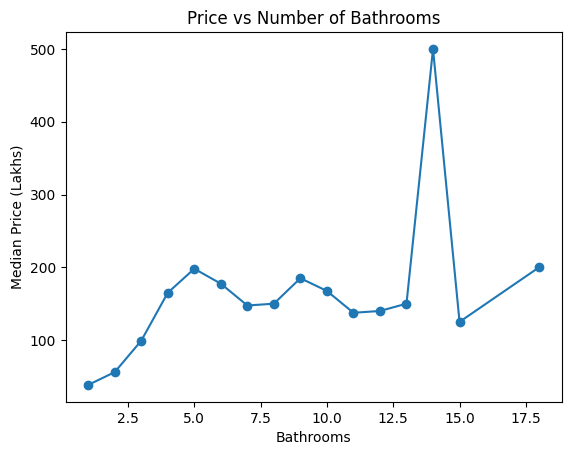

In [26]:
df.groupby('bath')['price'].median().plot(kind='line', marker='o')
plt.xlabel('Bathrooms')
plt.ylabel('Median Price (Lakhs)')
plt.title('Price vs Number of Bathrooms')
plt.show()

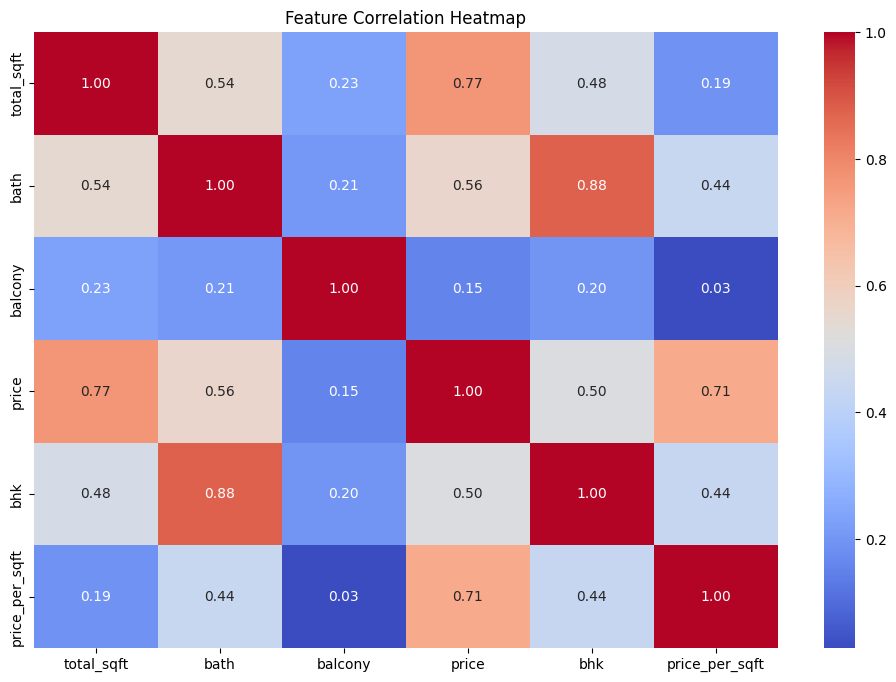

In [27]:
# Correlation Heatmap
numerical_df = df_final.select_dtypes(include=['number'])
plt.figure(figsize=(12,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()
 

In [28]:
 # Save final clean dataset
df_final.to_csv('Bengaluru_House_Data_Engineered.csv', index=False)

**Model Building and Evaluation**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [30]:
# Load the cleaned dataset
df_final = pd.read_csv('Bengaluru_House_Data_Engineered.csv')
df_final

,availability,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,location_1st Phase JP Nagar,...,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,19-Dec,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.810606,False,...,False,False,False,False,False,False,False,False,False,True
1,Ready To Move,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.384615,False,...,False,False,False,False,False,False,False,False,True,False
2,Ready To Move,3 BHK,Unknown,1440.0,2.0,3.0,62.00,3,4305.555556,False,...,False,False,False,False,False,False,False,False,False,False
3,Ready To Move,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.890861,False,...,False,False,False,False,False,False,False,False,False,True
4,Ready To Move,2 BHK,Unknown,1200.0,2.0,1.0,51.00,2,4250.000000,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12554,Ready To Move,3 BHK,SoosePr,1715.0,3.0,3.0,112.00,3,6530.612245,False,...,False,False,False,False,False,False,False,False,False,True
12555,Ready To Move,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5,6689.834926,False,...,True,False,False,False,False,False,False,False,False,False
12556,Ready To Move,4 BHK,Unknown,3600.0,5.0,2.0,400.00,4,11111.111111,False,...,False,False,False,False,False,False,True,False,False,True
12557,Ready To Move,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2,5258.545136,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
# Separate features (X) and target (y)
X =df_final[['total_sqft', 'bath', 'balcony', 'bhk', 'price_per_sqft']]
y =df_final['price']

In [32]:
 # Train-test split
 # 80%train, 20% test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
 # Build Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
 # Predict on test set
y_pred = lr_model.predict(X_test)

In [36]:
# Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [38]:
print(f"RMSE (on test data): {rmse:.2f} lakhs")
print(f"R² Score (on test data): {r2:.2f}")



RMSE (on test data): 21.92 lakhs
R² Score (on test data): 0.93


In [39]:
# Compare Actual vs Predicted Prices

comparison = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print(comparison.head())

      Actual Price  Predicted Price
2020         45.00        36.384389
8790         71.22        74.381078
7947         49.00        42.397209
4404        140.00       143.919824
357          77.00        76.707152
